# 🤖 05 – Model Training (Fraud Detection)

In this notebook, we train machine learning models to classify whether 
a transaction is fraudulent. We handle class imbalance, train multiple models, 
and evaluate them using metrics suitable for fraud detection.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv("../data/engineered_data.csv")
df.head()

,cc_num,merchant,amt,gender,zip,lat,long,city_pop,dob,unix_time,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,2703186189652095,"fraud_Rippin, Kub and Mann",4.97,F,28654,36.0788,-81.1781,3495,1988-03-09,1325376018,...,False,False,False,False,True,False,False,False,False,False
1,630423337322,"fraud_Heller, Gutmann and Zieme",107.23,F,99160,48.8878,-118.2105,149,1978-06-21,1325376044,...,True,False,False,False,False,False,False,False,False,False
2,38859492057661,fraud_Lind-Buckridge,220.11,M,83252,42.1808,-112.2620,4154,1962-01-19,1325376051,...,False,False,False,False,False,False,False,False,False,False
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",45.00,M,59632,46.2306,-112.1138,1939,1967-01-12,1325376076,...,False,False,False,False,False,False,False,False,False,False
4,375534208663984,fraud_Keeling-Crist,41.96,M,24433,38.4207,-79.4629,99,1986-03-28,1325376186,...,False,False,False,False,False,True,False,False,False,False


In [2]:
X = df.drop("is_fraud", axis=1)

# ONLY numeric columns
X = X.select_dtypes(include=['int64','float64'])

y = df["is_fraud"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
X.dtypes

cc_num           int64
amt            float64
zip              int64
lat            float64
long           float64
city_pop         int64
unix_time        int64
merch_lat      float64
merch_long     float64
hour             int64
day              int64
month            int64
weekday          int64
is_weekend       int64
age              int64
distance_km    float64
dtype: object

In [5]:
cols_to_drop = [
    'merchant', 'street', 'city', 'state', 'zip', 
    'lat', 'long', 'merch_lat', 'merch_long', 
    'dob', 'trans_num'
]

for col in cols_to_drop:
    if col in X.columns:
        X = X.drop(columns=[col])

In [6]:
X = X.select_dtypes(include=['int64', 'float64'])

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Select only numeric features for modeling
X = df.drop("is_fraud", axis=1)
X = X.select_dtypes(include=['int64','float64'])
y = df['is_fraud']

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight="balanced", max_iter=500)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [11]:
pred_lr = lr.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, pred_lr))

print("ROC-AUC:")
print(roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    368549
           1       0.07      0.76      0.13      1930

    accuracy                           0.95    370479
   macro avg       0.54      0.86      0.55    370479
weighted avg       0.99      0.95      0.97    370479

ROC-AUC:
0.8620976194319927


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [13]:
pred_rf = rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, pred_rf))

print("ROC-AUC:")
print(roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.15      0.90      0.25      1930

    accuracy                           0.97    370479
   macro avg       0.57      0.94      0.62    370479
weighted avg       1.00      0.97      0.98    370479

ROC-AUC:
0.9865746706412323


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds),
        "F1-score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    }

lr_metrics = get_metrics(lr, X_test_scaled, y_test)
rf_metrics = get_metrics(rf, X_test, y_test)

results = pd.DataFrame([lr_metrics, rf_metrics], index=["LogisticRegression", "RandomForest"])
results

,Accuracy,Precision,Recall,F1-score,ROC-AUC
LogisticRegression,0.947884,0.072434,0.762694,0.132303,0.862098
RandomForest,0.972495,0.147911,0.898964,0.254026,0.986575


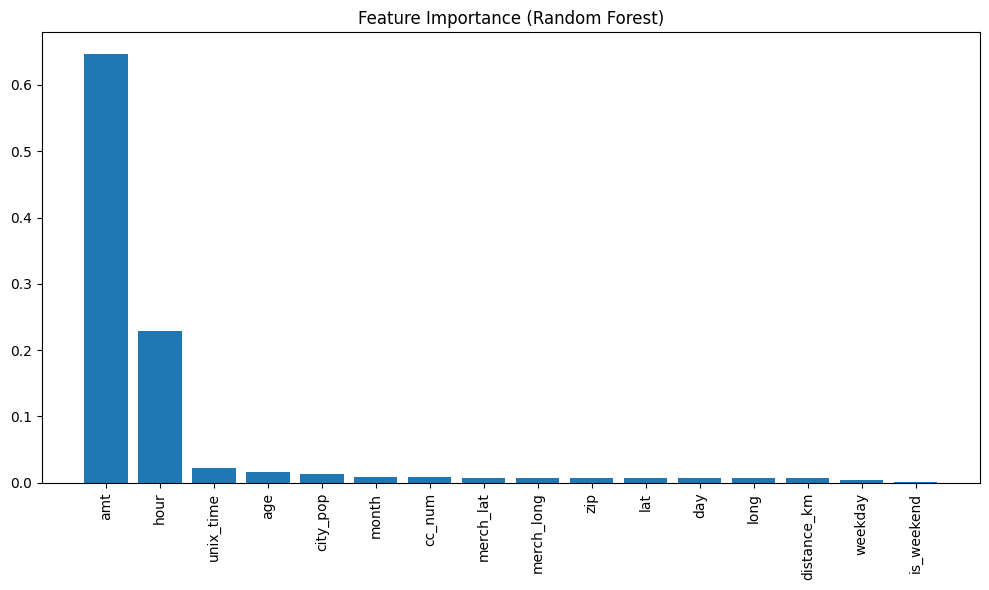

In [15]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()

### 🔍 Feature Importance Insights

- `distance_km` was one of the strongest predictors of fraud  
- `amt` (transaction amount) also had high importance  
- Time-based features like `hour` and `weekday` show patterns  
- One-hot encoded categories contributed meaningfully  

In [16]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(rf, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']